Dataset Overview

This analysis uses a food processing inventory dataset created for tracking raw material expiry dates, inventory levels, and finished goods production.

The objective is to identify inventory patterns, potential wastage risks, and stock management insights.

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [99]:
data = pd.read_csv('/content/HimShakti_Inventory_Expiry_Dataset_1000Rows.csv')
print(data.head(5))
data.shape

  Batch_ID Raw_Material  Entry_Date Expiry_Date  Quantity_KG  \
0    B0001        Onion  2025-10-16  2025-11-28          300   
1    B0002       Tomato  2025-11-23  2026-04-26          482   
2    B0003       Carrot  2024-08-11  2024-10-24           77   
3    B0004        Onion  2025-03-05  2025-05-15          334   
4    B0005       Potato  2024-12-14  2025-03-10          831   

   Remaining_Quantity_KG Production_Date   Finished_Good  Shelf_Life_Days  
0                    114      2025-10-16          Pickle              170  
1                     16      2025-11-25          Pickle              332  
2                     71      2024-08-27       Snack Mix              338  
3                      3      2025-03-19  Dehydrated Mix              331  
4                    344      2024-12-18          Pickle              140  


(1000, 9)

In [100]:
data.isnull().sum()

,0
Batch_ID,0
Raw_Material,0
Entry_Date,0
Expiry_Date,0
Quantity_KG,0
Remaining_Quantity_KG,0
Production_Date,0
Finished_Good,0
Shelf_Life_Days,0


In [101]:
data.duplicated().sum()

np.int64(0)

In [102]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Batch_ID               1000 non-null   object
 1   Raw_Material           1000 non-null   object
 2   Entry_Date             1000 non-null   object
 3   Expiry_Date            1000 non-null   object
 4   Quantity_KG            1000 non-null   int64 
 5   Remaining_Quantity_KG  1000 non-null   int64 
 6   Production_Date        1000 non-null   object
 7   Finished_Good          1000 non-null   object
 8   Shelf_Life_Days        1000 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 70.4+ KB


In [103]:
data['Entry_Date'] = pd.to_datetime(data['Entry_Date'])
data['Expiry_Date'] = pd.to_datetime(data['Expiry_Date'])
data['Production_Date'] = pd.to_datetime(data['Production_Date'])

In [104]:
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(" ", "_")

In [105]:
data.head()

,batch_id,raw_material,entry_date,expiry_date,quantity_kg,remaining_quantity_kg,production_date,finished_good,shelf_life_days
0,B0001,Onion,2025-10-16,2025-11-28,300,114,2025-10-16,Pickle,170
1,B0002,Tomato,2025-11-23,2026-04-26,482,16,2025-11-25,Pickle,332
2,B0003,Carrot,2024-08-11,2024-10-24,77,71,2024-08-27,Snack Mix,338
3,B0004,Onion,2025-03-05,2025-05-15,334,3,2025-03-19,Dehydrated Mix,331
4,B0005,Potato,2024-12-14,2025-03-10,831,344,2024-12-18,Pickle,140


In [106]:
data.count()

,0
batch_id,1000
raw_material,1000
entry_date,1000
expiry_date,1000
quantity_kg,1000
remaining_quantity_kg,1000
production_date,1000
finished_good,1000
shelf_life_days,1000


Dataset Dimensions

This output shows the total number of rows and columns present in the dataset.
It helps understand the overall size of the data being analyzed.

In [107]:
print("Dataset Shape:",data.shape)

Dataset Shape: (1000, 9)


Summary Statistics

The describe() function provides statistical information such as:

- Count
- Mean
- Standard Deviation
- Minimum Value
- Maximum Value

This helps understand the distribution of numerical variables.

In [108]:
data.describe()

,entry_date,expiry_date,quantity_kg,remaining_quantity_kg,production_date,shelf_life_days
count,1000,1000,1000.000000,1000.000000,1000,1000.000000
mean,2024-12-28 04:12:00,2025-04-04 11:34:04.799999744,515.840000,260.901000,2025-01-11 20:26:52.800000,203.599000
min,2024-01-01 00:00:00,2024-02-02 00:00:00,50.000000,0.000000,2024-01-07 00:00:00,30.000000
25%,2024-06-17 00:00:00,2024-09-27 18:00:00,271.500000,78.000000,2024-07-02 00:00:00,116.750000
50%,2024-12-22 00:00:00,2025-04-06 00:00:00,516.000000,196.000000,2025-01-07 00:00:00,207.000000
75%,2025-07-09 06:00:00,2025-10-10 00:00:00,756.000000,397.000000,2025-07-22 00:00:00,289.000000
max,2025-12-31 00:00:00,2026-06-24 00:00:00,998.000000,928.000000,2026-01-24 00:00:00,365.000000
std,NaN,NaN,274.522927,216.793793,NaN,98.237848


In [109]:
data.columns

Index(['batch_id', 'raw_material', 'entry_date', 'expiry_date', 'quantity_kg',
       'remaining_quantity_kg', 'production_date', 'finished_good',
       'shelf_life_days'],
      dtype='object')

Raw Material Frequency Analysis

This analysis shows how frequently each raw material appears in the inventory records.

It helps identify the most commonly used raw materials.

In [110]:
data['raw_material'].value_counts()

,count
raw_material,
Potato,137
Spinach,136
Ginger,128
Onion,127
Cabbage,127
Chili,122
Carrot,117
Tomato,106


Correlation Analysis

The correlation matrix helps identify relationships between numerical variables.

Values close to:
- +1 indicate a strong positive relationship
- -1 indicate a strong negative relationship
- 0 indicate little or no relationship

In [116]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   batch_id               1000 non-null   object        
 1   raw_material           1000 non-null   object        
 2   entry_date             1000 non-null   datetime64[ns]
 3   expiry_date            1000 non-null   datetime64[ns]
 4   quantity_kg            1000 non-null   int64         
 5   remaining_quantity_kg  1000 non-null   int64         
 6   production_date        1000 non-null   datetime64[ns]
 7   finished_good          1000 non-null   object        
 8   shelf_life_days        1000 non-null   int64         
dtypes: datetime64[ns](3), int64(3), object(3)
memory usage: 70.4+ KB


In [111]:
corr_matrix = data.corr(numeric_only=True)

corr_matrix



,quantity_kg,remaining_quantity_kg,shelf_life_days
quantity_kg,1.000000,0.662260,-0.035397
remaining_quantity_kg,0.662260,1.000000,-0.047441
shelf_life_days,-0.035397,-0.047441,1.000000


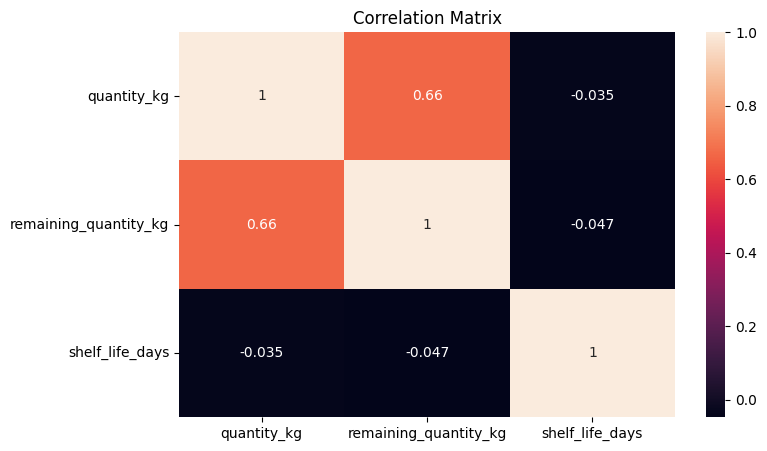

In [112]:
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

Interpretation

The correlation matrix indicates the strength of relationships between inventory-related numerical variables.

Strong positive values suggest variables tend to increase together, while values near zero indicate weak relationships.

## Inventory Quantity Distribution

This histogram shows how inventory quantities are distributed across different batches.

It helps identify whether inventory levels are concentrated in a specific range.

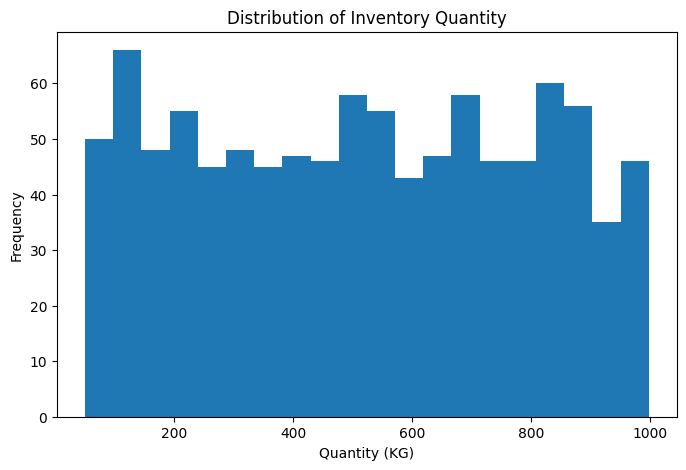

In [113]:
plt.figure(figsize=(8,5))

plt.hist(data['quantity_kg'], bins=20)

plt.title('Distribution of Inventory Quantity')
plt.xlabel('Quantity (KG)')
plt.ylabel('Frequency')

plt.show()

## Raw Material Distribution

This chart shows the number of records associated with each raw material.

It helps identify the most frequently stocked materials.

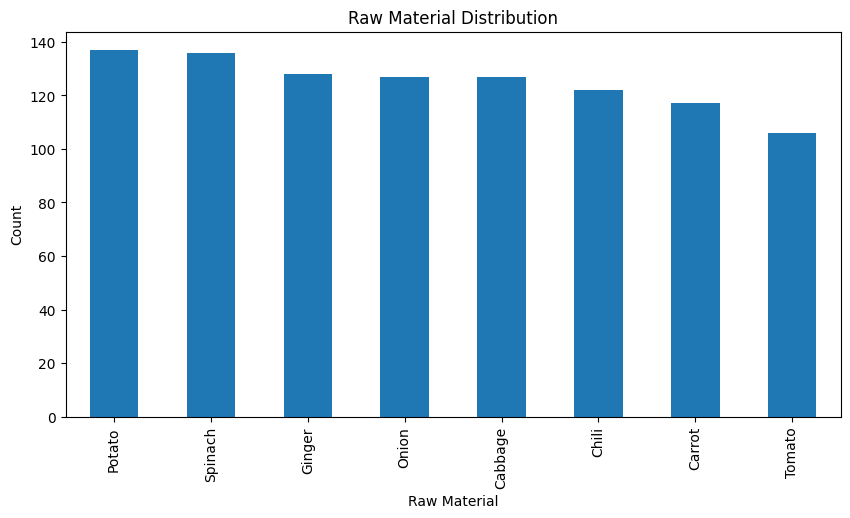

In [114]:
data['raw_material'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Raw Material Distribution')
plt.xlabel('Raw Material')
plt.ylabel('Count')

plt.show()

Conclusion

1. The dataset contains 1000 inventory records covering multiple raw materials and finished goods.

2. Certain raw materials appear significantly more frequently than others, indicating higher usage demand.

3. Inventory quantities vary across batches, suggesting different procurement and production requirements.

4. Correlation analysis helps understand relationships between inventory quantities and remaining stock levels.

5. Visual analysis highlights stock distribution patterns that can support better inventory planning and waste reduction strategies.